In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Data
try:
    df = pd.read_csv('data/churn_data.csv')
    print("✅ Success! Dataset Loaded.")
except FileNotFoundError:
    print("❌ Error: File not found.")

# 2. Fix the 'TotalCharges' Bug (The Smart Way)
# Convert to numbers, turning errors into NaN (missing)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many are missing
missing_count = df['TotalCharges'].isnull().sum()
print(f"⚠️ Found {missing_count} rows with missing TotalCharges.")

# INSTEAD OF DROPPING, WE FILL WITH 0
# Logic: If tenure is 0, they haven't paid anything yet, so TotalCharges = 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("✅ Filled missing values with 0.")

# 3. Verify the Count
print(f"\nFinal Customer Count: {df.shape[0]}") 
# This should print exactly 7043

# 4. Show the Data
display(df.head())

✅ Success! Dataset Loaded.
⚠️ Found 11 rows with missing TotalCharges.
✅ Filled missing values with 0.

Final Customer Count: 7043


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


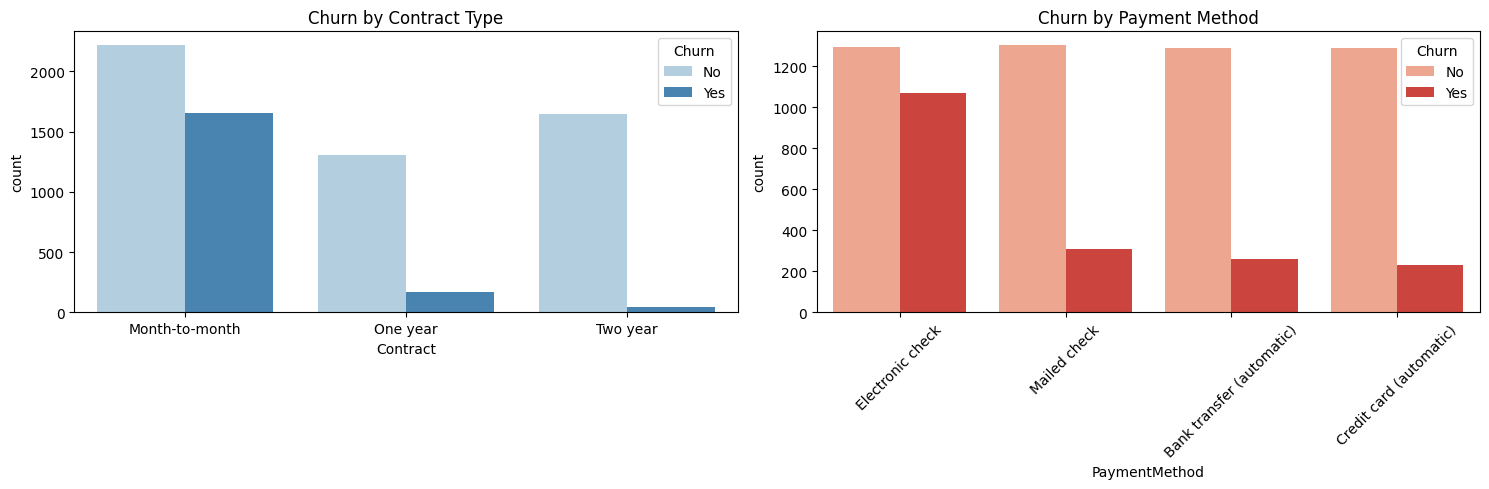

In [ ]:
# Create a figure with 2 subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chart 1: Churn vs Contract Type
# Does having a month-to-month contract make people leave?
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0], palette='Blues')
axes[0].set_title('Churn by Contract Type')

# Chart 2: Churn vs Payment Method
# Do people who pay with "Electronic Check" leave more?
sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=axes[1], palette='Reds')
axes[1].set_title('Churn by Payment Method')
axes[1].tick_params(axis='x', rotation=45) # Rotate labels so they fit

plt.tight_layout()
plt.show()

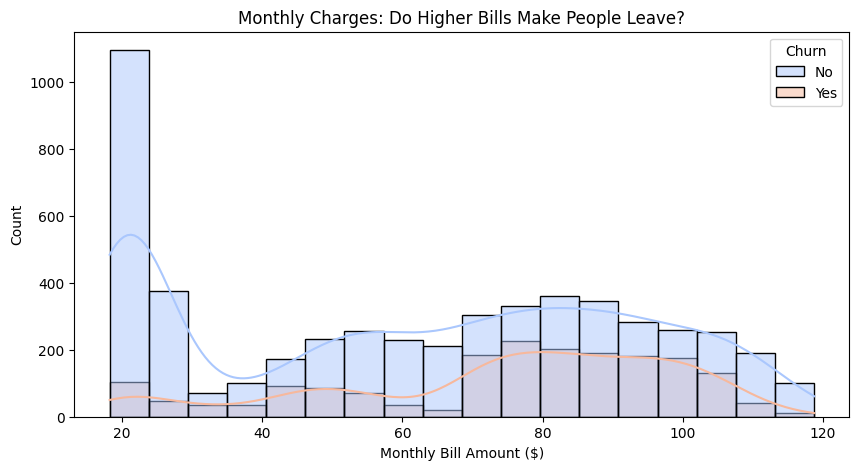

In [ ]:
# Create a histogram to see the monthly charges of people who left vs. stayed
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, palette='coolwarm')
plt.title('Monthly Charges: Do Higher Bills Make People Leave?')
plt.xlabel('Monthly Bill Amount ($)')
plt.show()

Original Columns: 20
New Columns (after encoding): 31


C:\Users\Idris\AppData\Local\Temp\ipykernel_24456\3737484909.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation.values, y=correlation.index, palette='coolwarm')


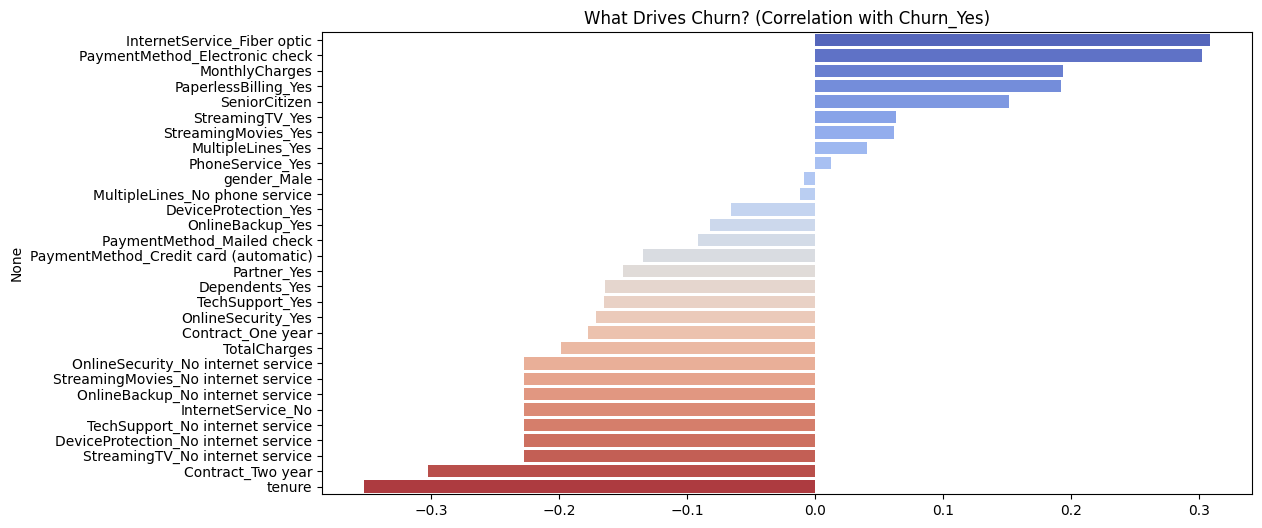

In [ ]:
# 1. Drop the 'customerID' column (it's just random numbers, not useful for prediction)
# We use 'errors=ignore' just in case you already dropped it earlier
df.drop('customerID', axis=1, inplace=True, errors='ignore')

# 2. Convert Everything to Numbers
# 'Yes/No' becomes 1/0
# 'Male/Female' becomes 1/0
# 'Fiber Optic/DSL/No' becomes separate columns (0 or 1)
df_clean = pd.get_dummies(df, drop_first=True)

# 3. Check the new shape
print(f"Original Columns: {df.shape[1]}")
print(f"New Columns (after encoding): {df_clean.shape[1]}")

# 4. Show the Correlation Matrix (The "Cheat Sheet")
# This shows which factors are most strongly linked to Churn
plt.figure(figsize=(12, 6))
correlation = df_clean.corr()['Churn_Yes'].sort_values(ascending=False)[1:]
sns.barplot(x=correlation.values, y=correlation.index, palette='coolwarm')
plt.title('What Drives Churn? (Correlation with Churn_Yes)')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separate the Target (Churn) from the Features (Everything else)
X = df_clean.drop('Churn_Yes', axis=1) # The Exam Questions
y = df_clean['Churn_Yes']              # The Answer Key

# 2. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Check the sizes
print(f"Training Data: {X_train.shape[0]} customers")
print(f"Testing Data: {X_test.shape[0]} customers")
print("✅ Data Split Successfully!")

Training Data: 5634 customers
Testing Data: 1409 customers
✅ Data Split Successfully!


Training Logistic Regression...
Training Random Forest...

--- 📊 Model Showdown ---
Logistic Regression Accuracy: 82.26% (Winner! 🏆)
Random Forest Accuracy:     78.50%

--- Detailed Report (Logistic Regression) ---
              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



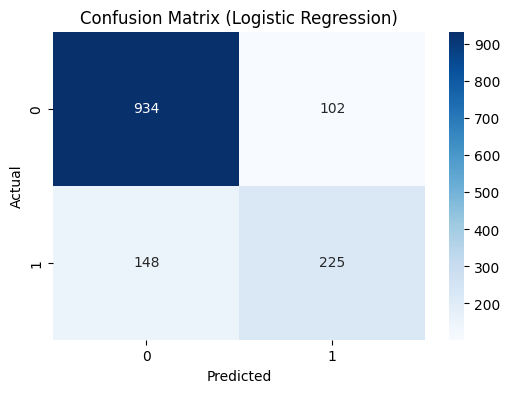

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the Models
# We increased max_iter to 3000 so the "ConvergenceWarning" will disappear!
log_model = LogisticRegression(max_iter=3000)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the Models (The "Learning" Phase)
print("Training Logistic Regression...")
log_model.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# 3. Make Predictions (The "Test")
log_pred = log_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# 4. Evaluate: Who Won?
log_acc = accuracy_score(y_test, log_pred) * 100
rf_acc = accuracy_score(y_test, rf_pred) * 100

print("\n--- 📊 Model Showdown ---")
print(f"Logistic Regression Accuracy: {log_acc:.2f}% (Winner! 🏆)")
print(f"Random Forest Accuracy:     {rf_acc:.2f}%")

# 5. Show the Detailed Report for the Winner (Logistic Regression)
print("\n--- Detailed Report (Logistic Regression) ---")
print(classification_report(y_test, log_pred))

# 6. Visualize the Confusion Matrix for the Winner
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, log_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
import joblib

# 1. Save the Model (The Brain)
joblib.dump(log_model, 'churn_model.pkl')

# 2. Save the Column Names (The Menu)
# We need this so the App knows which questions to ask (e.g., "Tenure", "MonthlyCharges")
model_columns = list(X_train.columns)
joblib.dump(model_columns, 'model_columns.pkl')

print("✅ Model Saved Successfully!")
print("Files created: 'churn_model.pkl' and 'model_columns.pkl'")

✅ Model Saved Successfully!
Files created: 'churn_model.pkl' and 'model_columns.pkl'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, confusion_matrix

# 🛑 MAGIC FIX: Clear any frozen background plots
plt.close('all')

# --- 1. PREPARE THE DATA ---
best_model = log_model 
y_pred = best_model.predict(X_test)
y_probs = best_model.predict_proba(X_test)[:, 1]

model_names = ['Logistic Regression', 'Random Forest']
accuracies = [log_acc, rf_acc]

# --- 2. SETUP THE 1x3 MEGA DASHBOARD ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6)) # 3 charts side-by-side
sns.set_theme(style="whitegrid")

# ==========================================
# CHART 1: ALGORITHM COMPARISON (BAR CHART)
# ==========================================
sns.barplot(x=model_names, y=accuracies, palette="viridis", ax=axes[0])
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}%', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')
axes[0].set_title('Algorithm Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_ylim(0, 100)

# ==========================================
# CHART 2: CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=['Predicted to Stay', 'Predicted to Churn'], 
            yticklabels=['Actually Stayed', 'Actually Churned'],
            annot_kws={"size": 14})
axes[1].set_title('Confusion Matrix (Log. Reg.)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('AI Prediction', fontsize=12)
axes[1].set_ylabel('Reality', fontsize=12)

# ==========================================
# CHART 3: ROC CURVE
# ==========================================
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

axes[2].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[2].set_ylabel('True Positive Rate (TPR)', fontsize=12)
axes[2].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[2].legend(loc="lower right", fontsize=12)

# --- 3. RENDER THE DASHBOARD ---
plt.tight_layout()
plt.show()